In [48]:
pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/71/34ddbd21f1da67c7a768146968b4d0220ee6831e4bcbad3e03dd3eae88b6/scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for scipy>=1.8.0 from https://files.pythonhosted.org/packages/d6/73/c449a7d56ba6e6f874183759f8483cde21f900a8be117d67ffbb670c2958/scipy-1.16.2-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.8 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 538.0 kB/s eta 0:00:00
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/1e/e8/685f47e0d754320684db4425a0967f7d3fa70126bffd76110b7009a0090f/joblib-1.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 f


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: C:\Users\marie\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

Load dataset

In [76]:
df = pd.read_csv("..\data\heart_disease.csv")

In [77]:
display(df.head(5))
print("Shape:" ,df.shape)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Shape: (303, 14)


Inspect dataset

In [78]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [79]:
print("Missing Values:\n",(df.isna().sum()/df.count())*100)

Missing Values:
 age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalach     0.000000
exang       0.000000
oldpeak     0.000000
slope       0.000000
ca          1.337793
thal        0.664452
target      0.000000
dtype: float64


In [80]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "target"]

imputer = SimpleImputer(strategy="median")
df[num_cols] = imputer.fit_transform(df[num_cols])

print("Missing values after:\n", df.isnull().sum())


Missing values after:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [81]:
df['target'] = df['target'].apply(lambda x: 1 if int(x) > 0 else 0)

In [82]:
encoder = OneHotEncoder(drop="first") 
encoded = encoder.fit_transform(df[categorical_features]).toarray()

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features))
# Drop original categorical columns and add encoded ones
df = df.drop(columns=categorical_features).reset_index(drop=True).join(encoded_df)


In [85]:
# Scale numerical features
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "target"]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

Exploratory Data Analysis (EDA)

Histogram for age

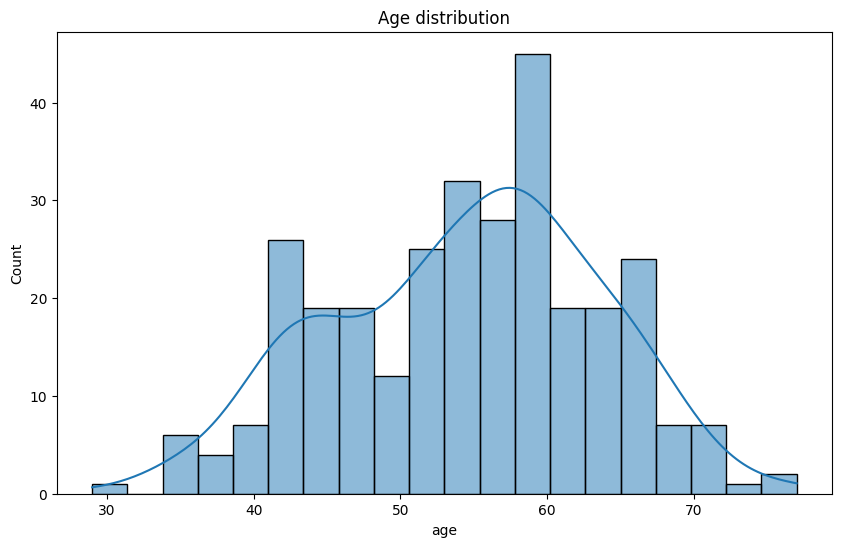

In [32]:
# Histogram for age
plt.figure(figsize=(10,6))
sns.histplot(df["age"],kde = True,bins=20)
plt.title("Age distribution")
plt.show()


<Axes: >

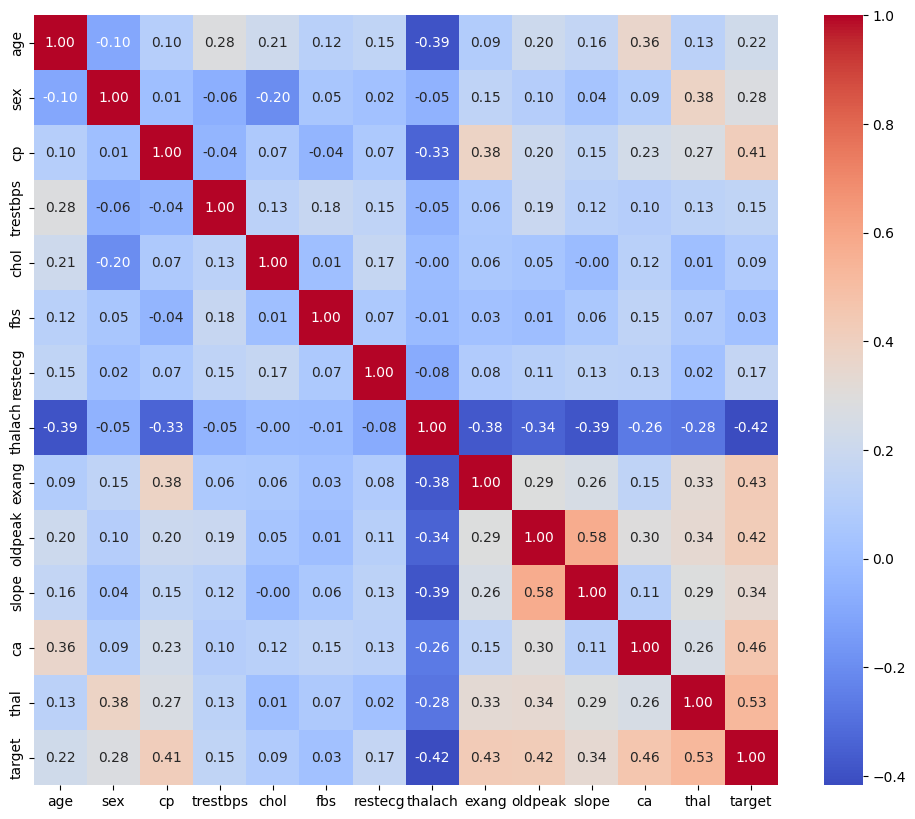

In [33]:
# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot = True, fmt = ".2f" , cmap = "coolwarm")

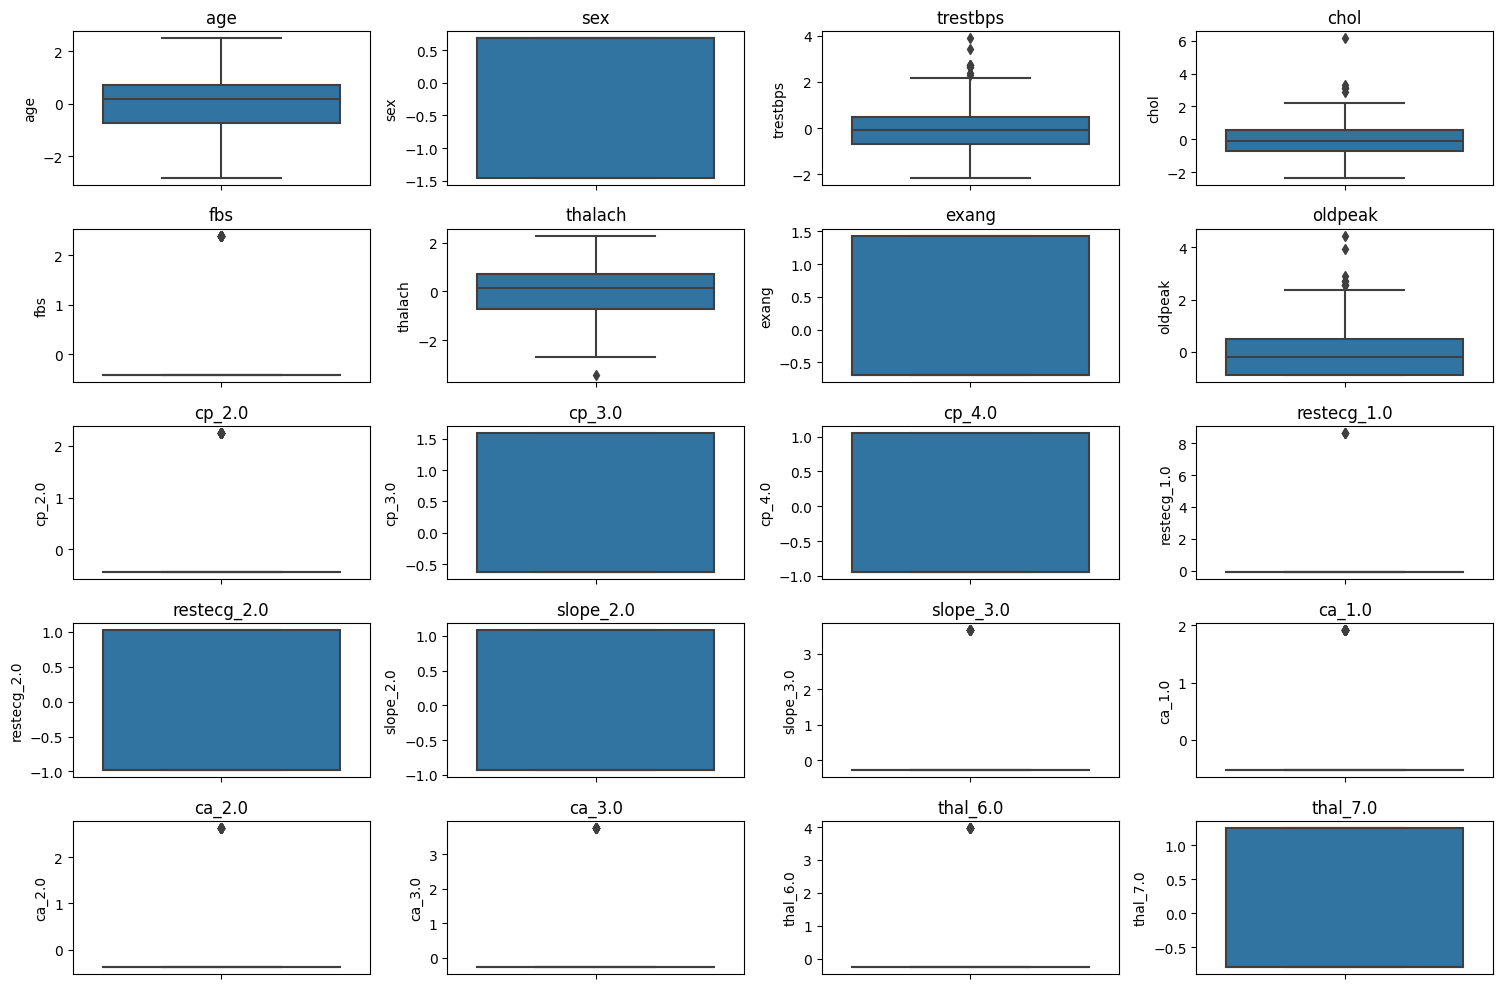

In [87]:
# Boxplots for numeric features
import math

# Get numeric columns (after encoding + dropping target)
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "target"]

# Calculate grid size
n_cols = 4  # number of plots per row
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [88]:
# Save cleaned dataset
# -----------------------------
df.to_csv("../data/heart_disease_cleaned.csv", index=False)
print("✅ Cleaned dataset saved to ../data/heart_disease_cleaned.csv")


✅ Cleaned dataset saved to ../data/heart_disease_cleaned.csv
